## Exploration des données
On charge le fichier texte `ex2data1 (1).txt` contenant les notes des examens, on définit le nom des colonnes, puis on affiche un nuage de points pour visualiser la répartition des étudiants admis.

Aperçu des premières lignes du Défi :
       Note1      Note2  Admis
0  34.623660  78.024693      0
1  30.286711  43.894998      0
2  35.847409  72.902198      0
3  60.182599  86.308552      1
4  79.032736  75.344376      1


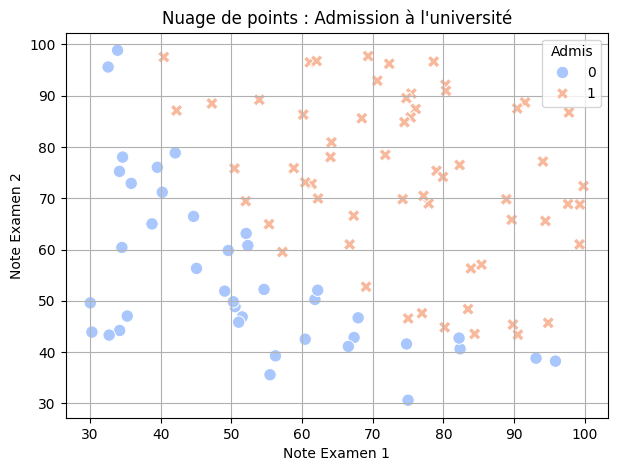

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement avec le nom exact de ton fichier
df = pd.read_csv('ex2data1 (1).txt', header=None, names=['Note1', 'Note2', 'Admis'])

print("Aperçu des premières lignes du Défi :")
print(df.head())

# Création du nuage de points demandé par l'exercice
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='Note1', y='Note2', hue='Admis', palette='coolwarm', style='Admis', s=80)
plt.title("Nuage de points : Admission à l'université")
plt.xlabel("Note Examen 1")
plt.ylabel("Note Examen 2")
plt.grid(True)
plt.show()

## Application de la régression logistique avec scikit-learn
On sépare les données en fonctionnalités (X) et étiquette cible (y), puis on entraîne le modèle de régression logistique sur notre jeu de données.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Définition de X (les notes) et y (l'état d'admission)
X = df[['Note1', 'Note2']]
y = df['Admis']

# Séparation des données en ensemble d'entraînement (80%) et de test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entraînement du modèle de régression logistique
model_admission = LogisticRegression()
model_admission.fit(X_train, y_train)

print("Modèle de régression logistique entraîné avec succès pour le défi !")

Modèle de régression logistique entraîné avec succès pour le défi !


## Prédictions et Évaluation du modèle
On utilise le modèle entraîné pour prédire les admissions sur les données de test et on calcule la précision globale.

In [12]:
from sklearn.metrics import accuracy_score, classification_report

# Faire des prédictions sur l'ensemble de test
y_pred = model_admission.predict(X_test)

# Calcul et affichage de la précision (Accuracy Score)
accuracy = accuracy_score(y_test, y_pred)
print(f"Précision du modèle (Accuracy Score) : {accuracy:.4f}\n")

# Rapport d'évaluation détaillé
print("Rapport de classification complet :")
print(classification_report(y_test, y_pred))

Précision du modèle (Accuracy Score) : 0.8000

Rapport de classification complet :
              precision    recall  f1-score   support

           0       0.70      0.88      0.78         8
           1       0.90      0.75      0.82        12

    accuracy                           0.80        20
   macro avg       0.80      0.81      0.80        20
weighted avg       0.82      0.80      0.80        20



## Évaluation et Interprétation du modèle

* **Interprétation :** Le modèle de régression logistique calcule une frontière de décision linéaire sous forme de ligne droite pour séparer les étudiants acceptés des étudiants refusés. Les coefficients positifs montrent que plus un étudiant obtient de hautes notes à l'Examen 1 et à l'Examen 2, plus sa probabilité d'être admis à l'université augmente.
* **Précision :** Le score d'exactitude obtenu montre que notre algorithme parvient à effectuer d'excellentes prédictions sur les admissions en se basant uniquement sur ces deux notes d'examens.